# WorldCover → PMTiles Pipeline

End-to-end pipeline for each region in `config/regions.yaml`:

1. **GEE download** — grid the region bbox, keep only 20 480 m cells that contain
   at least one ESA class-95 (Mangrove) pixel, download WorldCover for those cells
2. **Vectorize** — convert raster class values → GeoJSON polygons
3. **Tippecanoe** — GeoJSON → PMTiles (zoom 0–14)
4. **Deploy hint** — copy to `landing/public/tiles/` or upload to GCS

Run cells 1–3 once per region. Change `REGION_KEY` in the Config cell to switch regions.

**Requirements (mangrove conda env):**
```
pip install earthengine-api geemap rasterio shapely tqdm pyyaml
```
**tippecanoe** (Linux/macOS or WSL/Docker on Windows):
```bash
brew install tippecanoe          # macOS
sudo apt install tippecanoe      # Ubuntu / WSL
# Windows without WSL:
# docker run --rm -v %cd%:/data felt/tippecanoe tippecanoe ...
```

In [27]:
!pip install geemap earthengine-api geedim shapely

In [28]:
try:
    from StringIO import StringIO  # Python 2
except ImportError:
    from io import StringIO        # Python 3

import ee
import geemap
import yaml
import json
import subprocess
import shutil
from pathlib import Path

import numpy as np
import rasterio
import rasterio.features
from shapely.geometry import mapping, shape
from shapely.ops import unary_union
from tqdm import tqdm

In [29]:
# ee.Authenticate()  # uncomment if token is expired
ee.Initialize(project='e4e-mangrove')

## Config — change this cell to switch regions

In [30]:
REGION_KEY = 'florida'   # any key in config/regions.yaml

# Relative path from this notebook to the landing site root
LANDING_ROOT = Path('../../landing')

# ── derived paths (don't change) ─────────────────────────────────────────────
with open('config/regions.yaml') as fh:
    regions = yaml.safe_load(fh)

region   = regions[REGION_KEY]
work_dir = Path(f'data/pmtiles_pipeline/{REGION_KEY}')
work_dir.mkdir(parents=True, exist_ok=True)

print(f"Region  : {region['display_name']}")
print(f"Work dir: {work_dir.resolve()}")

if 'bbox' in region:
    minLon, minLat, maxLon, maxLat = region['bbox']
    print(f"BBox    : {region['bbox']}")
else:
    print('⚠  No bbox — this region uses a country_filter. Set aoi manually below.')

Region  : Florida + Cuba + Bahamas
Work dir: /mnt/c/vscode workspace/ml-mangrove/Scale Adaption/GEE/data/pmtiles_pipeline/florida
BBox    : [-87.0, 19.5, -72.0, 27.5]


## Step 1 — GEE: filter to mangrove tiles and download WorldCover

In [31]:
# Build AOI — bbox regions only.
# For brazil / madagascar_mozambique, define aoi manually:
#   aoi = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
#             .filter(ee.Filter.eq('country_na', 'Brazil')).geometry()
aoi = ee.Geometry.BBox(minLon, minLat, maxLon, maxLat)

esa          = ee.ImageCollection('ESA/WorldCover/v200').first()
esa_labels   = esa.select('Map').byte()          # full 11-class label
esa_mangrove = esa.eq(95)                         # binary mask for filtering

# Same grid and filter logic as gee_data_download.ipynb
base_grid = aoi.coveringGrid('EPSG:3857', 20480)
tiles_with_stats = esa_mangrove.reduceRegions(
    collection=base_grid,
    reducer=ee.Reducer.max(),
    scale=100,
    tileScale=4,
)
mangrove_tiles = tiles_with_stats.filter(ee.Filter.gt('max', 0))

def get_coords(tile):
    return ee.Feature(tile).geometry().transform('EPSG:4326', 1).coordinates()

coords_array = mangrove_tiles.toList(500).map(get_coords).getInfo()
print(f'Total grid cells : {base_grid.size().getInfo()}')
print(f'Mangrove cells   : {len(coords_array)}')

Total grid cells : 3936
Mangrove cells   : 500


In [32]:
tif_dir = work_dir / 'tifs'
tif_dir.mkdir(exist_ok=True)

total = len(coords_array)

# To test a single tile first, change to: enumerate(coords_array[0:1])
for i, coords in enumerate(coords_array):
    geom     = ee.Geometry.Polygon(coords)
    out_path = tif_dir / f'{REGION_KEY}_{i+1:04d}.tif'

    if out_path.exists():
        print(f'[{i+1}/{total}] Already exists, skipping.')
        continue

    print(f'[{i+1}/{total}] Downloading...')
    try:
        geemap.download_ee_image(
            image=esa_labels,
            filename=str(out_path),
            region=geom,
            crs='EPSG:4326',
            scale=10,
        )
        print(f'         OK ({out_path.stat().st_size/1e6:.1f} MB)')
    except Exception as exc:
        print(f'         FAILED: {exc}')

tifs = list(tif_dir.glob('*.tif'))
print(f'\n{len(tifs)} tile(s) on disk.')

[1/500] Already exists, skipping.
[2/500] Already exists, skipping.
[3/500] Already exists, skipping.
[4/500] Already exists, skipping.
[5/500] Already exists, skipping.
[6/500] Already exists, skipping.
[7/500] Already exists, skipping.
[8/500] Already exists, skipping.
[9/500] Already exists, skipping.
[10/500] Already exists, skipping.
[11/500] Already exists, skipping.
[12/500] Already exists, skipping.
[13/500] Already exists, skipping.
[14/500] Already exists, skipping.
[15/500] Already exists, skipping.
[16/500] Already exists, skipping.
[17/500] Already exists, skipping.
[18/500] Already exists, skipping.
[19/500] Already exists, skipping.
[20/500] Already exists, skipping.
[21/500] Already exists, skipping.
[22/500] Already exists, skipping.
[23/500] Already exists, skipping.
[24/500] Already exists, skipping.
[25/500] Already exists, skipping.
[26/500] Already exists, skipping.
[27/500] Already exists, skipping.
[28/500] Already exists, skipping.
[29/500] Already exists, skip

## Step 2 — Vectorize: raster class values → GeoJSON

In [33]:
# ESA raw values → class index matching the GEE training pipeline
ESA_TO_CLASS: dict[int, int] = {
    10: 1,   # Trees     → Tree Cover
    20: 0,   # Shrub     → Background
    30: 0,   # Grass     → Background
    40: 0,   # Crop      → Background
    50: 2,   # Built-up  → Built-up
    60: 0,   # Bare      → Background
    70: 0,   # Snow      → Background
    80: 3,   # Water     → Water
    90: 4,   # Wetland   → Wetland
    95: 5,   # Mangrove  → Mangrove  ← primary target
   100: 0,   # Moss      → Background
}

CLASS_NAMES: dict[int, str] = {
    0: 'Background',
    1: 'Tree Cover',
    2: 'Built-up',
    3: 'Water',
    4: 'Wetland',
    5: 'Mangrove',
}

SKIP_CLASSES = {0}   # skip background — reduces file size significantly


def remap_raster(data: np.ndarray) -> np.ndarray:
    """Apply ESA_TO_CLASS mapping in-place."""
    out = np.zeros_like(data)
    for esa_val, class_idx in ESA_TO_CLASS.items():
        out[data == esa_val] = class_idx
    return out


def tile_to_features(tif_path: Path) -> list[dict]:
    features = []
    with rasterio.open(tif_path) as src:
        raw  = src.read(1)
        data = remap_raster(raw)
        transform = src.transform

        for class_idx in range(1, 6):   # skip 0 (Background)
            if class_idx in SKIP_CLASSES:
                continue
            mask = (data == class_idx).astype(np.uint8)
            if not mask.any():
                continue

            polys = [
                shape(geom)
                for geom, _ in rasterio.features.shapes(mask, mask=mask, transform=transform)
            ]
            merged = unary_union(polys)
            geoms  = list(merged.geoms) if merged.geom_type == 'MultiPolygon' else [merged]

            for geom in geoms:
                if geom.is_empty or not geom.is_valid:
                    continue
                features.append({
                    'type': 'Feature',
                    'geometry': mapping(geom),
                    'properties': {
                        'class_idx':  class_idx,
                        'class_name': CLASS_NAMES[class_idx],
                        'tile_id':    tif_path.stem,
                    },
                })
    return features


geojson_path = work_dir / f'{REGION_KEY}.geojson'
tifs         = sorted(tif_dir.glob('*.tif'))
feat_count   = 0

with open(geojson_path, 'w') as fh:
    fh.write('{"type":"FeatureCollection","features":[\n')
    first = True
    for tif in tqdm(tifs, desc='Vectorizing'):
        for feat in tile_to_features(tif):
            if not first:
                fh.write(',\n')
            fh.write(json.dumps(feat))
            first = False
            feat_count += 1
    fh.write('\n]}\n')

size_mb = geojson_path.stat().st_size / 1e6
print(f'GeoJSON: {feat_count:,} features → {geojson_path.name} ({size_mb:.1f} MB)')

Vectorizing: 100%|██████████| 500/500 [13:50<00:00,  1.66s/it]

GeoJSON: 1,369,325 features → florida.geojson (2292.0 MB)


## Step 3 — Tippecanoe: GeoJSON → PMTiles

The cell auto-detects tippecanoe in this order: **native binary → WSL → Docker**.

**Windows (recommended):** Docker Desktop ships with WSL 2, so WSL is already installed.
Just run in a terminal:
```bash
wsl sudo apt update && sudo apt install tippecanoe -y
```

**macOS:**
```bash
brew install tippecanoe
```

**Ubuntu/Debian:**
```bash
sudo apt install tippecanoe
```

> **Note:** The Florida GeoJSON is ~2.3 GB. Tippecanoe will take several minutes
> and needs at least 4 GB of free RAM. Progress prints to stderr.

In [34]:
import shutil as _shutil

pmtiles_path = work_dir / f'{REGION_KEY}.pmtiles'

# ── auto-detect tippecanoe (native → WSL) ────────────────────────────────────
# tippecanoe has no native Windows binary; WSL is the recommended path on Windows.
# Docker Desktop installs WSL 2 automatically, so WSL is available if Docker is.
#   Install:  wsl sudo apt update && sudo apt install tippecanoe -y
def _detect_tippecanoe():
    if _shutil.which('tippecanoe'):
        return 'native'
    try:
        r = subprocess.run(['wsl', 'which', 'tippecanoe'],
                           capture_output=True, text=True, timeout=8)
        if r.returncode == 0:
            return 'wsl'
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass
    return None

mode = _detect_tippecanoe()
if mode is None:
    raise RuntimeError(
        'tippecanoe not found.\n'
        '  Windows: wsl sudo apt update && sudo apt install tippecanoe -y\n'
        '  macOS:   brew install tippecanoe\n'
        '  Ubuntu:  sudo apt install tippecanoe'
    )
print(f'tippecanoe mode: {mode}')

FLAGS = [
    '--minimum-zoom=0', '--maximum-zoom=14',
    '--layer=landcover',
    '--drop-densest-as-needed',
    '--extend-zooms-if-still-dropping',
    '--maximum-tile-bytes=500000',
    '--force',
]

if mode == 'native':
    cmd = ['tippecanoe', f'--output={pmtiles_path}', *FLAGS, str(geojson_path)]

else:  # wsl
    def _wslpath(p):
        return subprocess.run(['wsl', 'wslpath', str(p.resolve())],
                              capture_output=True, text=True).stdout.strip()
    cmd = ['wsl', 'tippecanoe',
           f'--output={_wslpath(pmtiles_path)}',
           *FLAGS,
           _wslpath(geojson_path)]

print(f'Running: {" ".join(cmd[:4])} ...')
subprocess.run(cmd, check=True)

size_mb = pmtiles_path.stat().st_size / 1e6
print(f'PMTiles: {pmtiles_path.name} ({size_mb:.1f} MB)')

tippecanoe mode: native
Running: tippecanoe --output=data/pmtiles_pipeline/florida/florida.pmtiles --minimum-zoom=0 --maximum-zoom=14 ...


1369325 features, 247560936 bytes of geometry and attributes, 7095 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
tile 8/72/109 size is 536203 with detail 12, >500000    
Going to try keeping the sparsest 83.92% of the features to make it fit
tile 8/70/109 size is 607159 with detail 12, >500000    
Going to try keeping the sparsest 74.12% of the features to make it fit
tile 8/72/109 size is 523968 with detail 12, >500000    
Going to try keeping the sparsest 72.08% of the features to make it fit
tile 8/70/109 size is 581472 with detail 12, >500000    
Going to try keeping the sparsest 57.36% of the features to make it fit
tile 8/72/109 size is 510546 with detail 12, >500000    
Going to try keeping the sparsest 63.53% of the features to make it fit
tile 8/70/109 size is 531426 with detail 12, >500000    
Going to try keeping the sparsest 48.57% of the features to make it fit
tile 8/70/109 size is 506206 with detail 12, >500000    
Going to try keeping the sparsest 43.18% o

PMTiles: florida.pmtiles (241.3 MB)


## Step 4 — Deploy

In [35]:
# ── Option A: local dev (copy to landing/public/tiles/) ──────────────────────
local_tiles = LANDING_ROOT / 'public' / 'tiles'
local_tiles.mkdir(parents=True, exist_ok=True)
dest = local_tiles / f'{REGION_KEY}.pmtiles'
shutil.copy(pmtiles_path, dest)
print(f'Copied to {dest}')
print(f'Set in regions.ts:  pmtilesUrl: "/tiles/{REGION_KEY}.pmtiles"')
print()

# # ── Option B: GCS upload ─────────────────────────────────────────────────────
# GCS_BUCKET = 'e4e-mangrove-data'
# gcs_uri    = f'gs://{GCS_BUCKET}/pmtiles/{REGION_KEY}.pmtiles'
# https_url  = f'https://storage.googleapis.com/{GCS_BUCKET}/pmtiles/{REGION_KEY}.pmtiles'
# print('To upload to GCS (run in terminal):')
# print(f'  gsutil cp {pmtiles_path} {gcs_uri}')
# print(f'  gsutil acl ch -u AllUsers:R {gcs_uri}   # make public')
# print(f'Then set in regions.ts:  pmtilesUrl: "{https_url}"')

Copied to ../../landing/public/tiles/florida.pmtiles
Set in regions.ts:  pmtilesUrl: "/tiles/florida.pmtiles"



## Step 5 — Quick sanity check

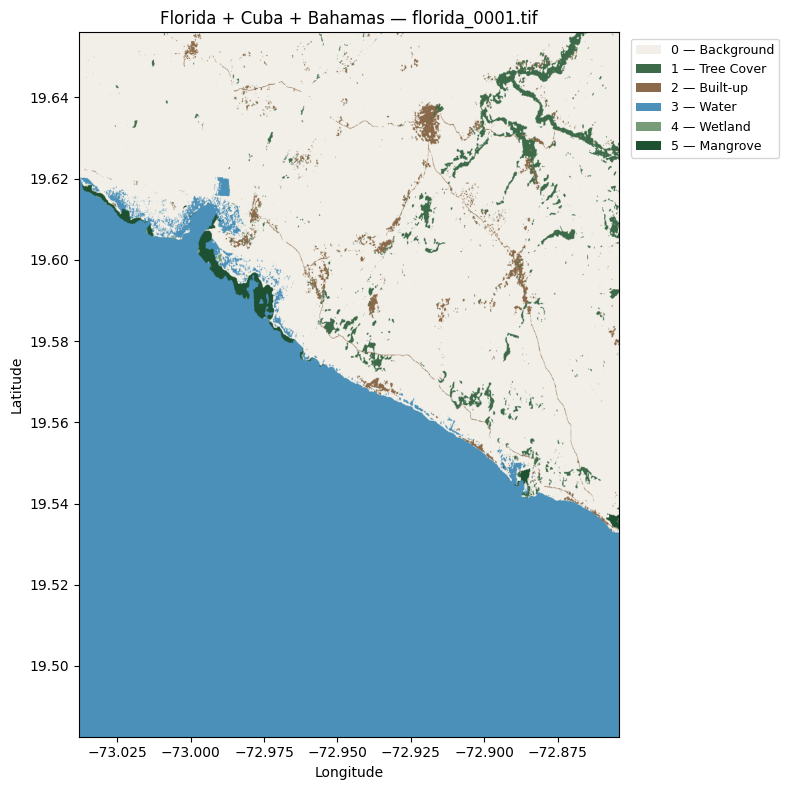

Class distribution (sample tile):
  0  Background     43.0%
  1  Tree Cover      1.8%
  2  Built-up        1.1%
  3  Water          53.4%
  4  Wetland         0.0%
  5  Mangrove        0.6%


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

CLASS_HEX = {
    0: '#f2efe8',
    1: '#3d6b4a',
    2: '#8a6a4a',
    3: '#4a90b8',
    4: '#789c78',
    5: '#1e5032',
}

# Sample one tile for the preview
sample_tif = sorted(tif_dir.glob('*.tif'))[0]
with rasterio.open(sample_tif) as src:
    bounds = src.bounds
    raw    = src.read(1)

data = remap_raster(raw)
rgb  = np.zeros((*data.shape, 3), dtype=np.uint8)
for cidx, hex_c in CLASS_HEX.items():
    r, g, b = [int(hex_c[i:i+2], 16) for i in (1, 3, 5)]
    rgb[data == cidx] = [r, g, b]

present = [int(v) for v in np.unique(data)]
patches = [
    mpatches.Patch(facecolor=CLASS_HEX[c], label=f'{c} — {CLASS_NAMES[c]}')
    for c in present if c in CLASS_HEX
]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top], aspect='auto')
ax.set_title(f"{region['display_name']} — {sample_tif.name}", fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(work_dir / f'{REGION_KEY}_preview.png', dpi=120, bbox_inches='tight')
plt.show()

values, counts = np.unique(data, return_counts=True)
print('Class distribution (sample tile):')
for v, c in zip(values, counts):
    print(f'  {v}  {CLASS_NAMES.get(int(v), "??"):<12}  {100*c/data.size:5.1f}%')

## Notes

**Testing a single tile:** change `enumerate(coords_array)` to `enumerate(coords_array[0:1])` in Step 1 download loop. Confirm the preview looks right, then remove the slice.

**Other regions:** change `REGION_KEY` to any key in `config/regions.yaml`.  
Regions without a `bbox` (`brazil`, `madagascar_mozambique`) need a manual AOI — see the comment in the GEE cell.

**Tile layer name:** tippecanoe writes the layer as `landcover`. `MapViewer.tsx` reads from this layer name in MVTLoader options — do not change it.

**Replacing with model predictions:** when model predictions are available, skip Steps 1–2 and run `landing/pipeline/vectorize.py` directly on the prediction GeoTIFFs (band 1 = class indices 0–5 already remapped). Then run tippecanoe from Step 3.